In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.model_selection import GridSearchCV

# Optional (if you want to tackle imbalance)
# from imblearn.over_sampling import SMOTE

# XGBoost / LightGBM – allowed by project
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
train_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

In [4]:
train_data

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,NaN,NaN,NaN,False,Why save people who are bent on self-destructi...,0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,NaN,NaN,NaN,False,Trudeau is not only undemocratic but also innu...,2
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,block all exports no humanitarian relief and a...,3
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,none,none,False,really black kids seeing that is better than g...,1


In [5]:
test_data

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101995,2023-09-26 03:14:06.328881+00:00,72,0,0,0,1,0,0,4,NaN,NaN,NaN,False,Working in McDonald's is easy (pain in the pos...
101996,2023-08-18 19:30:16.601996+00:00,71,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please prov..."
101997,2023-10-26 15:41:55.972421+00:00,72,0,0,0,0,5,4,4,none,none,none,False,Cry us a river..\n\nhttp://www.celebritynetwor...
101998,2024-02-28 11:25:10.033561+00:00,72,1,0,0,0,0,0,4,NaN,NaN,NaN,False,tggv What does that have to do with Trudeau no...


EDA

In [6]:
train_data.size

2970000

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [8]:
train_data.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [9]:
print("Before:", train_data.shape)

train_data = train_data.dropna(subset=["comment"])
train_data= train_data.drop(columns=['post_id','race','religion','gender'])
train_data["comment_len"] = train_data["comment"].astype(str).str.len()


print("After:", train_data.shape)


Before: (198000, 15)
After: (197999, 12)


In [10]:
print("Before:", test_data.shape)

test_data = test_data.dropna(subset=["comment"])
test_data= test_data.drop(columns=['post_id','race','religion','gender'])
test_data["comment_len"] = test_data["comment"].astype(str).str.len()


print("After:", test_data.shape)


Before: (102000, 14)
After: (102000, 11)


In [11]:
train_data["created_date"] = pd.to_datetime(train_data["created_date"])
test_data["created_date"] = pd.to_datetime(test_data["created_date"])

train_data["created_year"] = train_data["created_date"].dt.year
train_data["created_month"] = train_data["created_date"].dt.month
train_data["created_day"] = train_data["created_date"].dt.day

test_data["created_year"] = test_data["created_date"].dt.year
test_data["created_month"] = test_data["created_date"].dt.month
test_data["created_day"] = test_data["created_date"].dt.day

In [12]:
import re
import string

URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN = re.compile(r'@\w+')

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)

    # normalize newlines and tabs
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')

    # replace URLs and @mentions with tokens (keeps semantic info)
    text = URL_PATTERN.sub(' URL ', text)
    text = MENTION_PATTERN.sub(' USER ', text)

    # lower case
    text = text.lower()

    # keep only basic ascii (drop weird unicode noise)
    text = text.encode('ascii', errors='ignore').decode('ascii')

    # keep ! and ? (can be important for emotion), remove other punctuation
    punct_to_remove = string.punctuation.replace('!', '').replace('?', '')
    text = text.translate(str.maketrans('', '', punct_to_remove))

    # normalize repeated characters: coooool -> coool
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove numbers but keep word boundaries
    text = re.sub(r'\d+', ' ', text)

    # collapse extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [13]:
train_data['disability'] = train_data['disability'].astype(int)
test_data['disability'] = test_data['disability'].astype(int)



In [14]:
text_col = 'comment'


numeric_features = [
    "emoticon_1",
    "emoticon_2",
    "emoticon_3",
    "upvote",
    "downvote",
    "if_1",
    "if_2",
    "comment_len",
    "created_year",
    "created_month",
    "created_day",
    "disability"
]

categorical_cols = []


target = 'label'

#X = train_data[Cat_features,numeric_features,text_col]
#y = train_data['label']

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
   # ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=5
    ))
])

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
      #  ("cat", categorical_transformer, categorical_cols),
        ("text", text_transformer, text_col),
    ],
    remainder="drop"
)

In [17]:
# Train/validation split on text only
X = train_data.drop(columns=[target])
y = train_data['label']
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
print("Train split shape:", X_train.shape)
print("Valid split shape:", X_valid.shape)


Train split shape: (158399, 14)
Valid split shape: (39600, 14)


In [19]:
logreg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=10000,
         solver='lbfgs',
        n_jobs=-1,
         multi_class='auto',
        C=1.0,
        class_weight="balanced"  # helpful if class imbalance
    ))
])

In [20]:
logreg_clf.fit(X_train, y_train)
y_pred_valid = logreg_clf.predict(X_valid)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [21]:
print("\n=== Logistic Regression Validation Performance ===")
print("Accuracy:", accuracy_score(y_valid, y_pred_valid))
print("Macro F1:", f1_score(y_valid, y_pred_valid, average="macro"))
print("\nClassification report:\n", classification_report(y_valid, y_pred_valid))



=== Logistic Regression Validation Performance ===
Accuracy: 0.8987878787878788
Macro F1: 0.7983771655497902

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.96     22834
           1       0.69      0.83      0.75      3184
           2       0.87      0.86      0.87     12488
           3       0.51      0.76      0.61      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.85      0.80     39600
weighted avg       0.91      0.90      0.90     39600



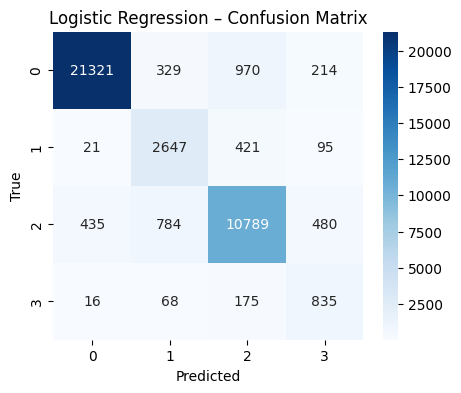

In [22]:
cm = confusion_matrix(y_valid, y_pred_valid)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

model2

In [23]:
rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

In [24]:
rf_clf.fit(X_train, y_train)
y_pred_valid_rf = rf_clf.predict(X_valid)


In [25]:
print("\n=== Random Forest Validation Performance ===")
print("Accuracy:", accuracy_score(y_valid, y_pred_valid_rf))
print("Macro F1:", f1_score(y_valid, y_pred_valid_rf, average="macro"))



=== Random Forest Validation Performance ===
Accuracy: 0.8997979797979798
Macro F1: 0.7381414319887182


8. Model 3 – Linear SVM (LinearSVC)

In [26]:
svm_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LinearSVC(
        C=1.0
    ))
])

In [27]:
svm_clf.fit(X_train, y_train)
y_pred_valid_svm = svm_clf.predict(X_valid)


In [28]:

print("\n=== Linear SVM Validation Performance ===")
print("Accuracy:", accuracy_score(y_valid, y_pred_valid_svm))
print("Macro F1:", f1_score(y_valid, y_pred_valid_svm, average="macro"))


=== Linear SVM Validation Performance ===
Accuracy: 0.786969696969697
Macro F1: 0.6730303813938113


# 9. Optional: Tuned Gradient Boosting Model (LightGBM)


In [29]:
lgbm_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LGBMClassifier(
        objective="multiclass",
        num_class=len(np.unique(y)),
        learning_rate=0.1,
        n_estimators=300,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])


In [30]:
lgbm_clf.fit(X_train, y_train)
y_pred_valid_lgbm = lgbm_clf.predict(X_valid)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 71.846317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1933042
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 49894
[LightGBM] [Info] Start training from score -0.550550
[LightGBM] [Info] Start training from score -2.520842
[LightGBM] [Info] Start training from score -1.154055
[LightGBM] [Info] Start training from score -3.589211


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [31]:
print("\n=== LightGBM Validation Performance ===")
print("Accuracy:", accuracy_score(y_valid, y_pred_valid_lgbm))
print("Macro F1:", f1_score(y_valid, y_pred_valid_lgbm, average="macro"))



=== LightGBM Validation Performance ===
Accuracy: 0.9132575757575757
Macro F1: 0.8092162099806262


# 10. Model Comparison Summary


In [32]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return {"model": name, "accuracy": acc, "macro_f1": f1}


In [33]:
results = []
results.append(evaluate_model("LogisticRegression", y_valid, y_pred_valid))
results.append(evaluate_model("RandomForest", y_valid, y_pred_valid_rf))
results.append(evaluate_model("LinearSVC", y_valid, y_pred_valid_svm))
results.append(evaluate_model("LightGBM", y_valid, y_pred_valid_lgbm))

results_df = pd.DataFrame(results)



In [34]:
print("\n=== Model Comparison on Validation Set ===")
print(results_df.sort_values(by="macro_f1", ascending=False))


=== Model Comparison on Validation Set ===
                model  accuracy  macro_f1
3            LightGBM  0.913258  0.809216
0  LogisticRegression  0.898788  0.798377
1        RandomForest  0.899798  0.738141
2           LinearSVC  0.786970  0.673030


In [35]:
final_model = lgbm_clf


# 11. (Optional) Hyperparameter Tuning Example (for one model)


# 12. Train Final Model on Full Training Data


In [36]:
test_predictions = final_model.predict(test_data)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [37]:
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
print(sample.head())



   ID  label
0   1      0
1   2      0
2   3      0
3   4      0
4   5      0


In [38]:

sample['label'] = test_predictions
sample.to_csv('submission.csv', index=False)

print("✅ Dummy submission file created!")


✅ Dummy submission file created!
